In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
from cartopy import crs as ccrs, feature as cfeature

# Load daily ET0 data in historical experiment for the 8 models 
MODELS = ["IPSL-CM6A-LR", "MIROC6", "MPI-ESM1-2-HR", "MPI-ESM1-2-LR", "MRI-ESM2-0", "NorESM2-LM", "NorESM2-MM", "UKESM1-0-LL"]

model_paths = {}
for model in MODELS:
    if model == "UKESM1-0-LL":
        path =  '/work10/archive/CMIP6/CMIP-SSPs/outputs/historical/ET0_day_UKESM1-0-LL_historical_18500101-20141230.nc'
    else:
        path = f"/work10/archive/CMIP6/CMIP-SSPs/outputs/historical/ET0_day_{model}_historical_18500101-20141231.nc"
    model_paths[model] = path

In [24]:
# Calculate mean from 1981 to 2000 and save as .nc files

START_YEAR = 1981
END_YEAR = 2000

model_means = {}
for model in model_paths.keys():
    ds = xr.open_dataset(model_paths[model], chunks={'time': 10*365})
    mean_30y = ds.ET0.sel(time=slice(str(START_YEAR), str(END_YEAR))).mean(dim='time')
    model_means[model] = mean_30y
    mean_30y.to_netcdf(f"30ymean/ET0_{model}_mean_{START_YEAR}-{END_YEAR}.nc")

print(f"✅ Saved {len(model_paths.keys())} files to /30ymean")

✅ Saved 8 files to /30ymean


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/work/home/H.mvelasco/miniconda3/envs/work/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/wor

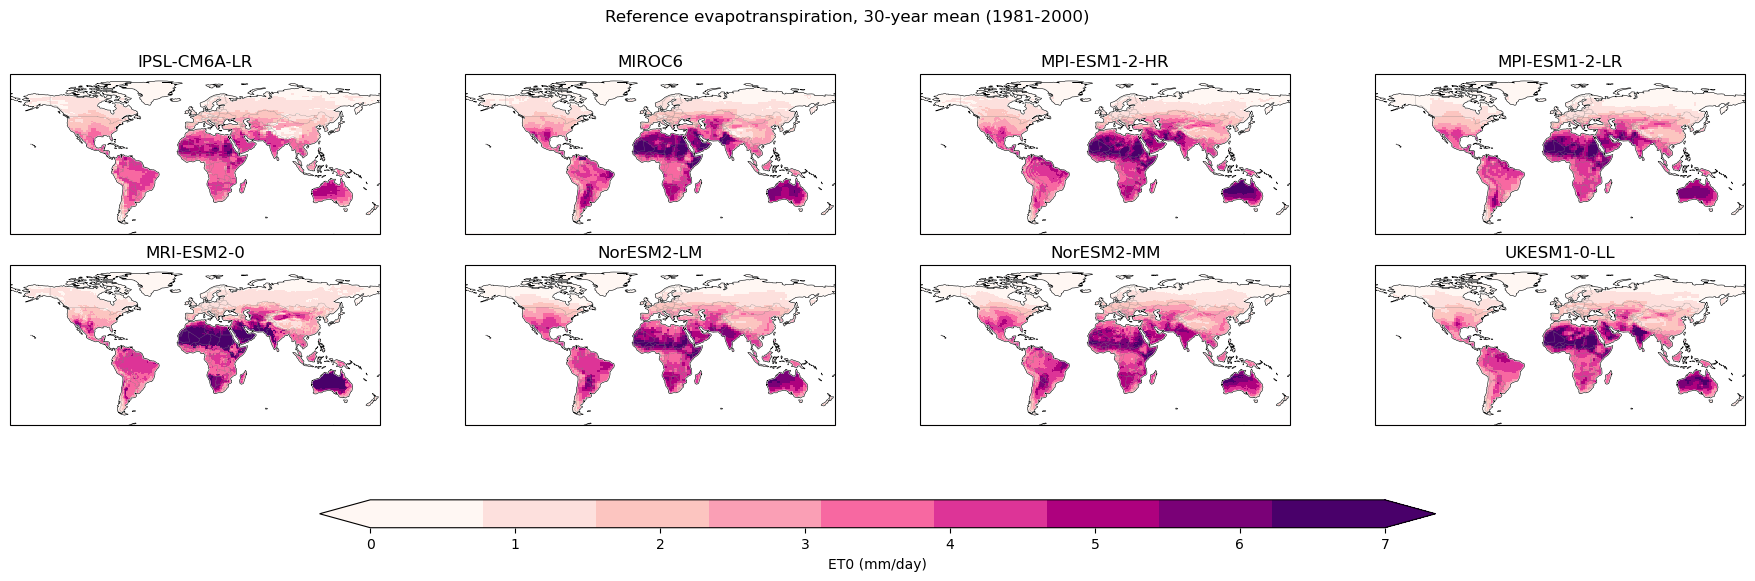

In [26]:
import colormaps as cmaps

fig, axes = plt.subplots(
    2, 4, figsize=(24, 6.5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Plot 30-year mean for each of the 8 models
for ax, (model, da) in zip(axes.flat, model_means.items()):
    im = da.plot(
        ax=ax, cmap=cmaps.rdpu, vmin=0, vmax=7,
        add_colorbar=False, transform=ccrs.PlateCarree(),
    )
    ax.set_extent([-180, 180, -65, 90], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, color="white", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, color="gray")
    ax.set_title(model)

# Adjust gaps between subplots
fig.subplots_adjust(wspace=-0.08, hspace=0.20)

# Add horizontal colorba
fig.colorbar(im, ax=axes, orientation="horizontal", shrink=0.6, aspect=40, label="ET0 (mm/day)", extend="both")
fig.suptitle("Reference evapotranspiration, 30-year mean (1981-2000)")

plt.savefig("et0_30y_mean_by_model.png", dpi=300, bbox_inches="tight")